# Dark photon lifetime — acceptance-corrected cτ at full statistics

**Inputs and selections.** Every distribution here is generator-level truth from the
canonical `truth_kinematics_forAN` output (all 180 v10 signal samples, every file,
unweighted), channel **`genOnly`**: status-1 generator leptons as the only object
definitions, **no reconstruction, trigger, or vertex requirements of any kind**. The
merged per-sample files and their metadata sidecars live at
`/store/group/lpcmetx/SIDM/coffea_outputs/murtazas/truth_kinematics_forAN/`.

The method is unchanged from `lifetime_study/lifetime_acceptance_correction.ipynb`
(same `lifetime_analysis` engine); this notebook reruns it at ~50× the statistics of
the original `max_files=1` pass and saves the analysis-note figures.

### The truncation model

A decay with proper length `x` and boost `βγ` travels `ℓlab = βγ·x` in the lab. The
generator drops decays beyond a fixed lab radius `R_max`, so the fraction of decays at
proper length `x` that survive is `ε(x) = P(βγ < R_max/x) = Fβγ(R_max/x)`, and the
observed proper density is `dN/dx ∝ exp(−x/cτ) · Fβγ(R_max/x)`. Fitting
`log(dN/dx) = logA − x/cτ + log Fβγ(R_max/x)` returns both the intrinsic cτ and the
lab cap `R_max`, with their covariance.

### Assumptions

1. **Sharp lab cap** — one fixed `R_max` for every sample (validated below).
2. **Boost independent of lifetime** — `Fβγ` per mass point comes from its
   shortest-cτ (faithful) anchor.
3. **Pure exponential intrinsic decay**, as generated.


In [1]:
import sys, os, importlib
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "lifetime_study"),
          os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
from sidm.tools import utilities
import lifetime_analysis as la
import an_style
importlib.reload(la)

utilities.set_plot_style(dpi=110)
CH = "genOnly"   # strictly generator-level channel: no evt cuts at all


In [2]:
from _lifetime_refit import load_truthkin
output = load_truthkin()
rows, groups, bg_mean = la.compute_grid(output, channel=CH)
bgs = [bg_mean[k] for k in bg_mean]
print(f"{len(groups)} mass points, {len(rows)} samples; "
      f"<betagamma> in [{min(bgs):.0f}, {max(bgs):.0f}]")


36 mass points, 180 samples; <betagamma> in [16, 2745]


## Every fit, batched by mass point

One panel per mass point with the cτ scan overlaid; the curve is the
acceptance-corrected fit `exp(−x/cτ)·Fβγ(R_max/x)` with its ±1σ band. The fit follows
the data through the turn-over where the lab cap bites.


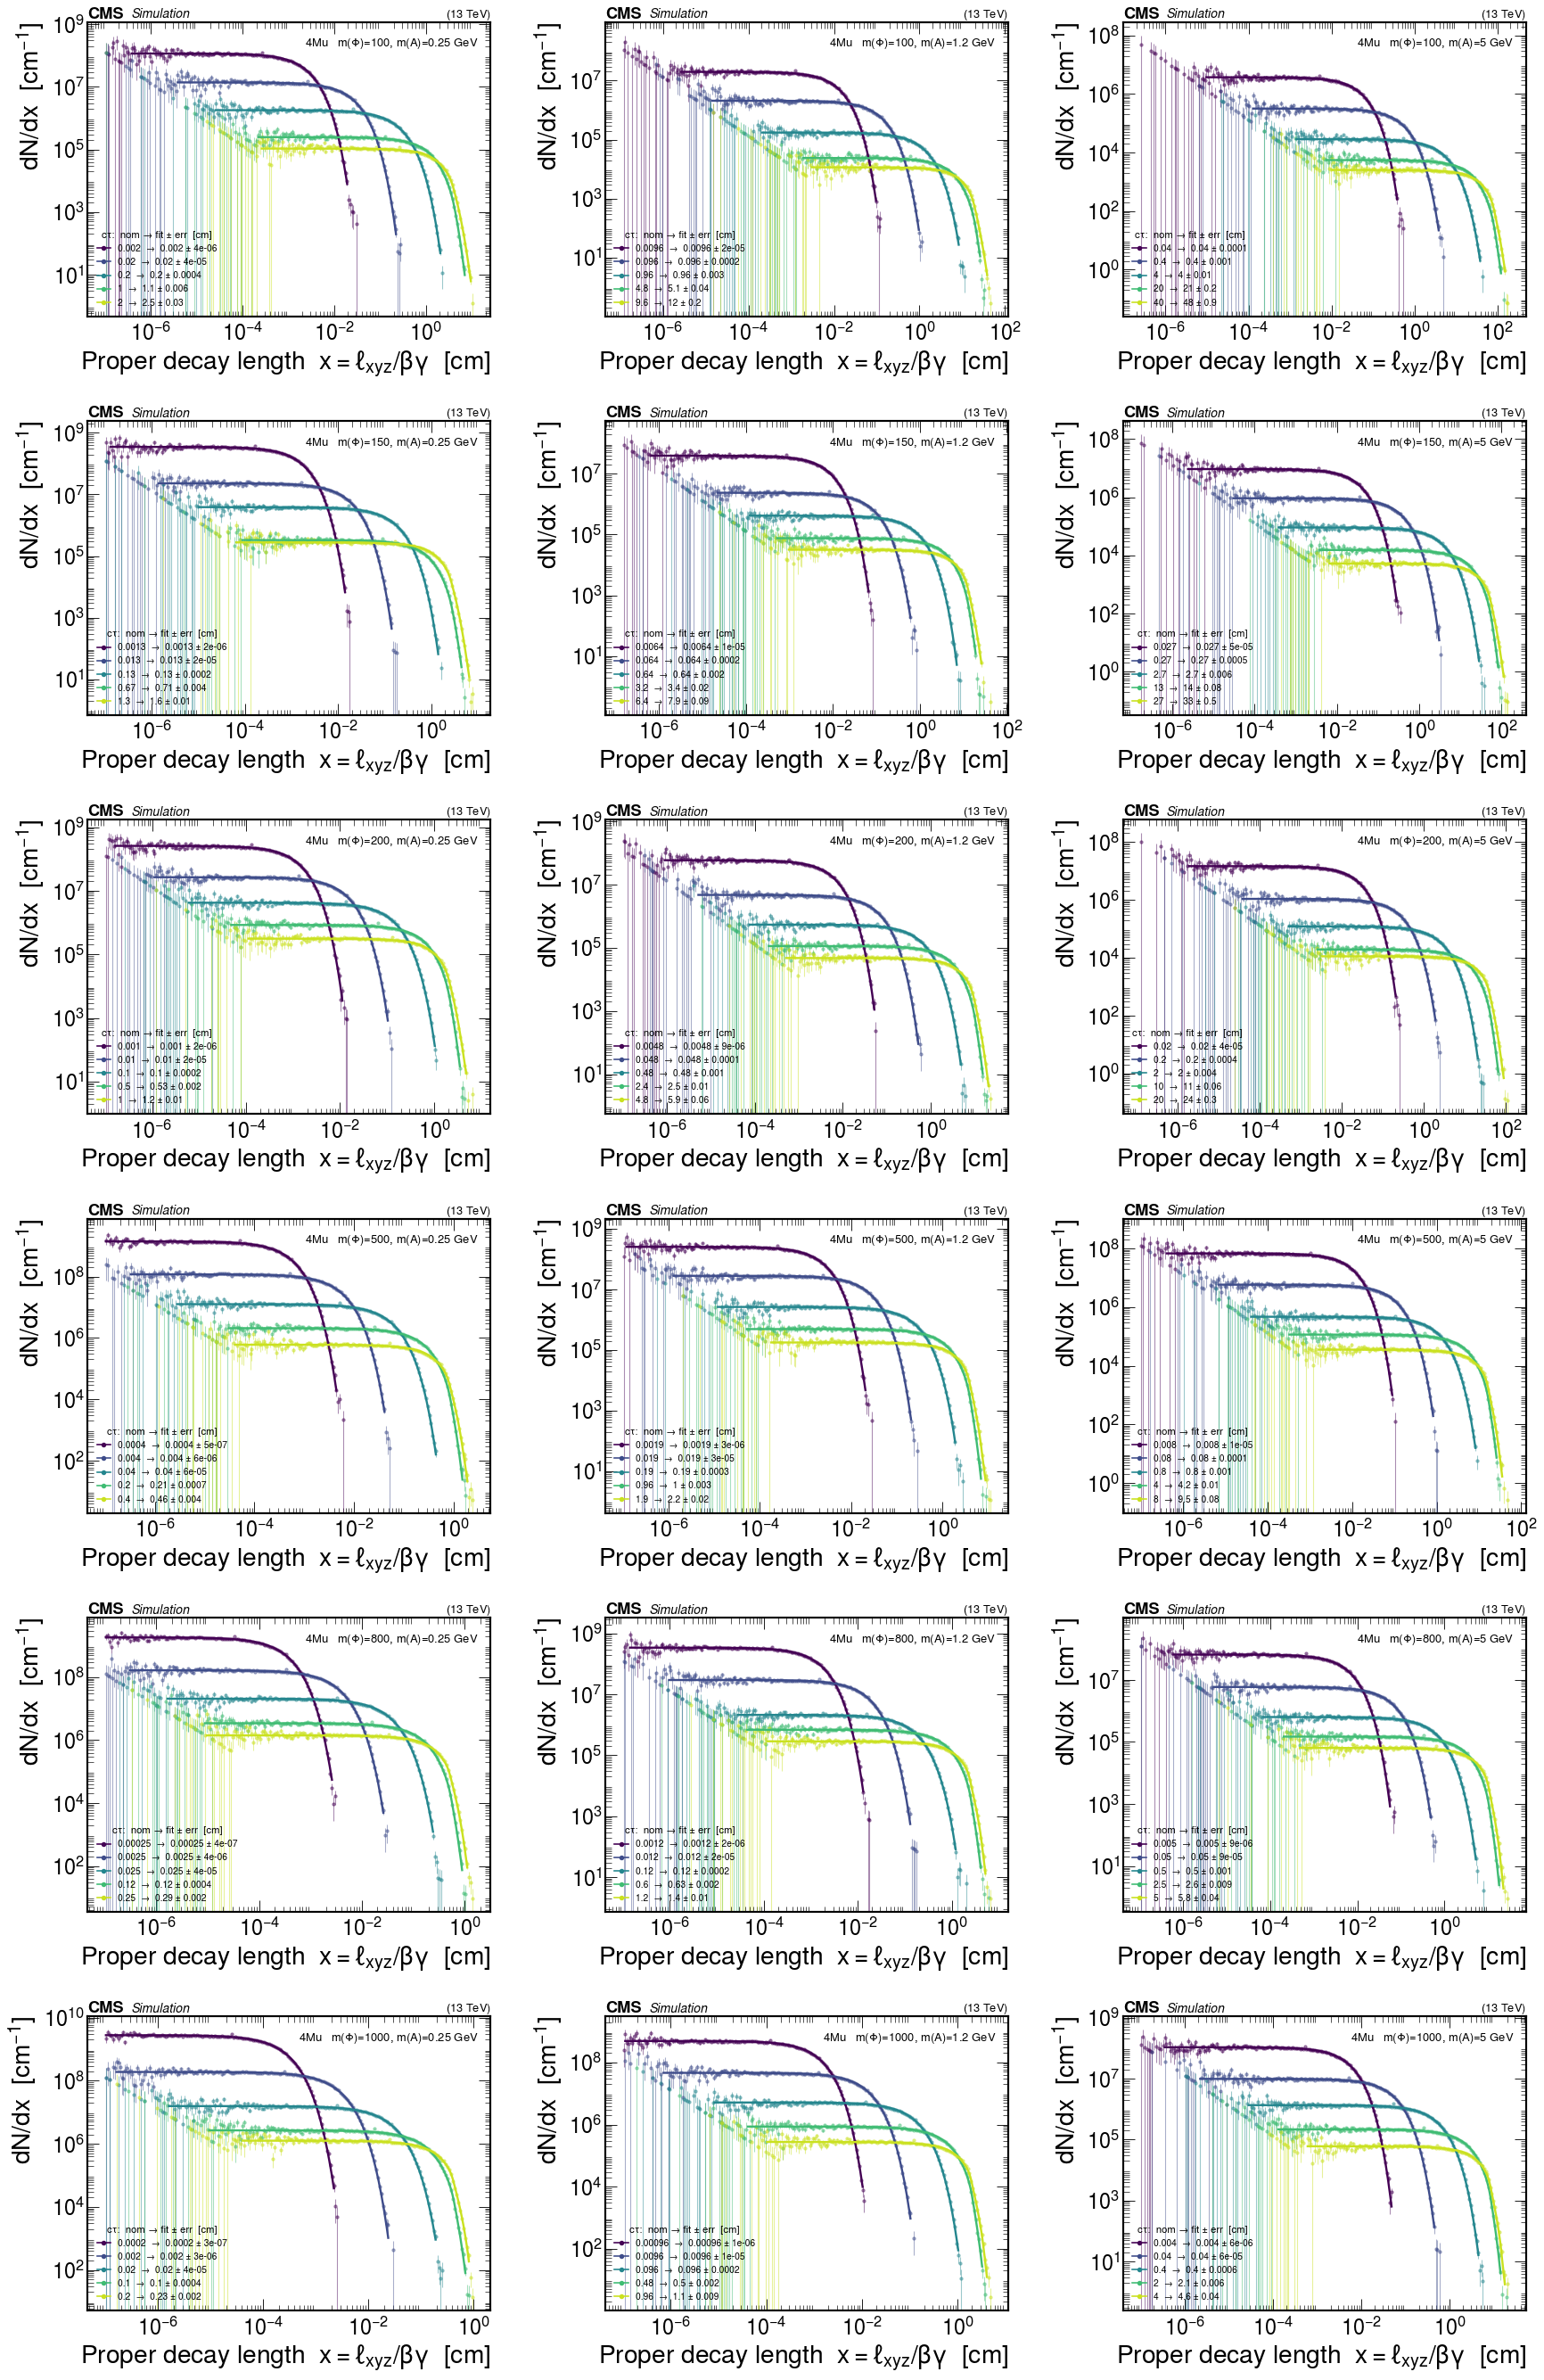

In [3]:
fig = la.plot_fit_grid(output, groups, "4Mu", kind="acceptance", channel=CH)


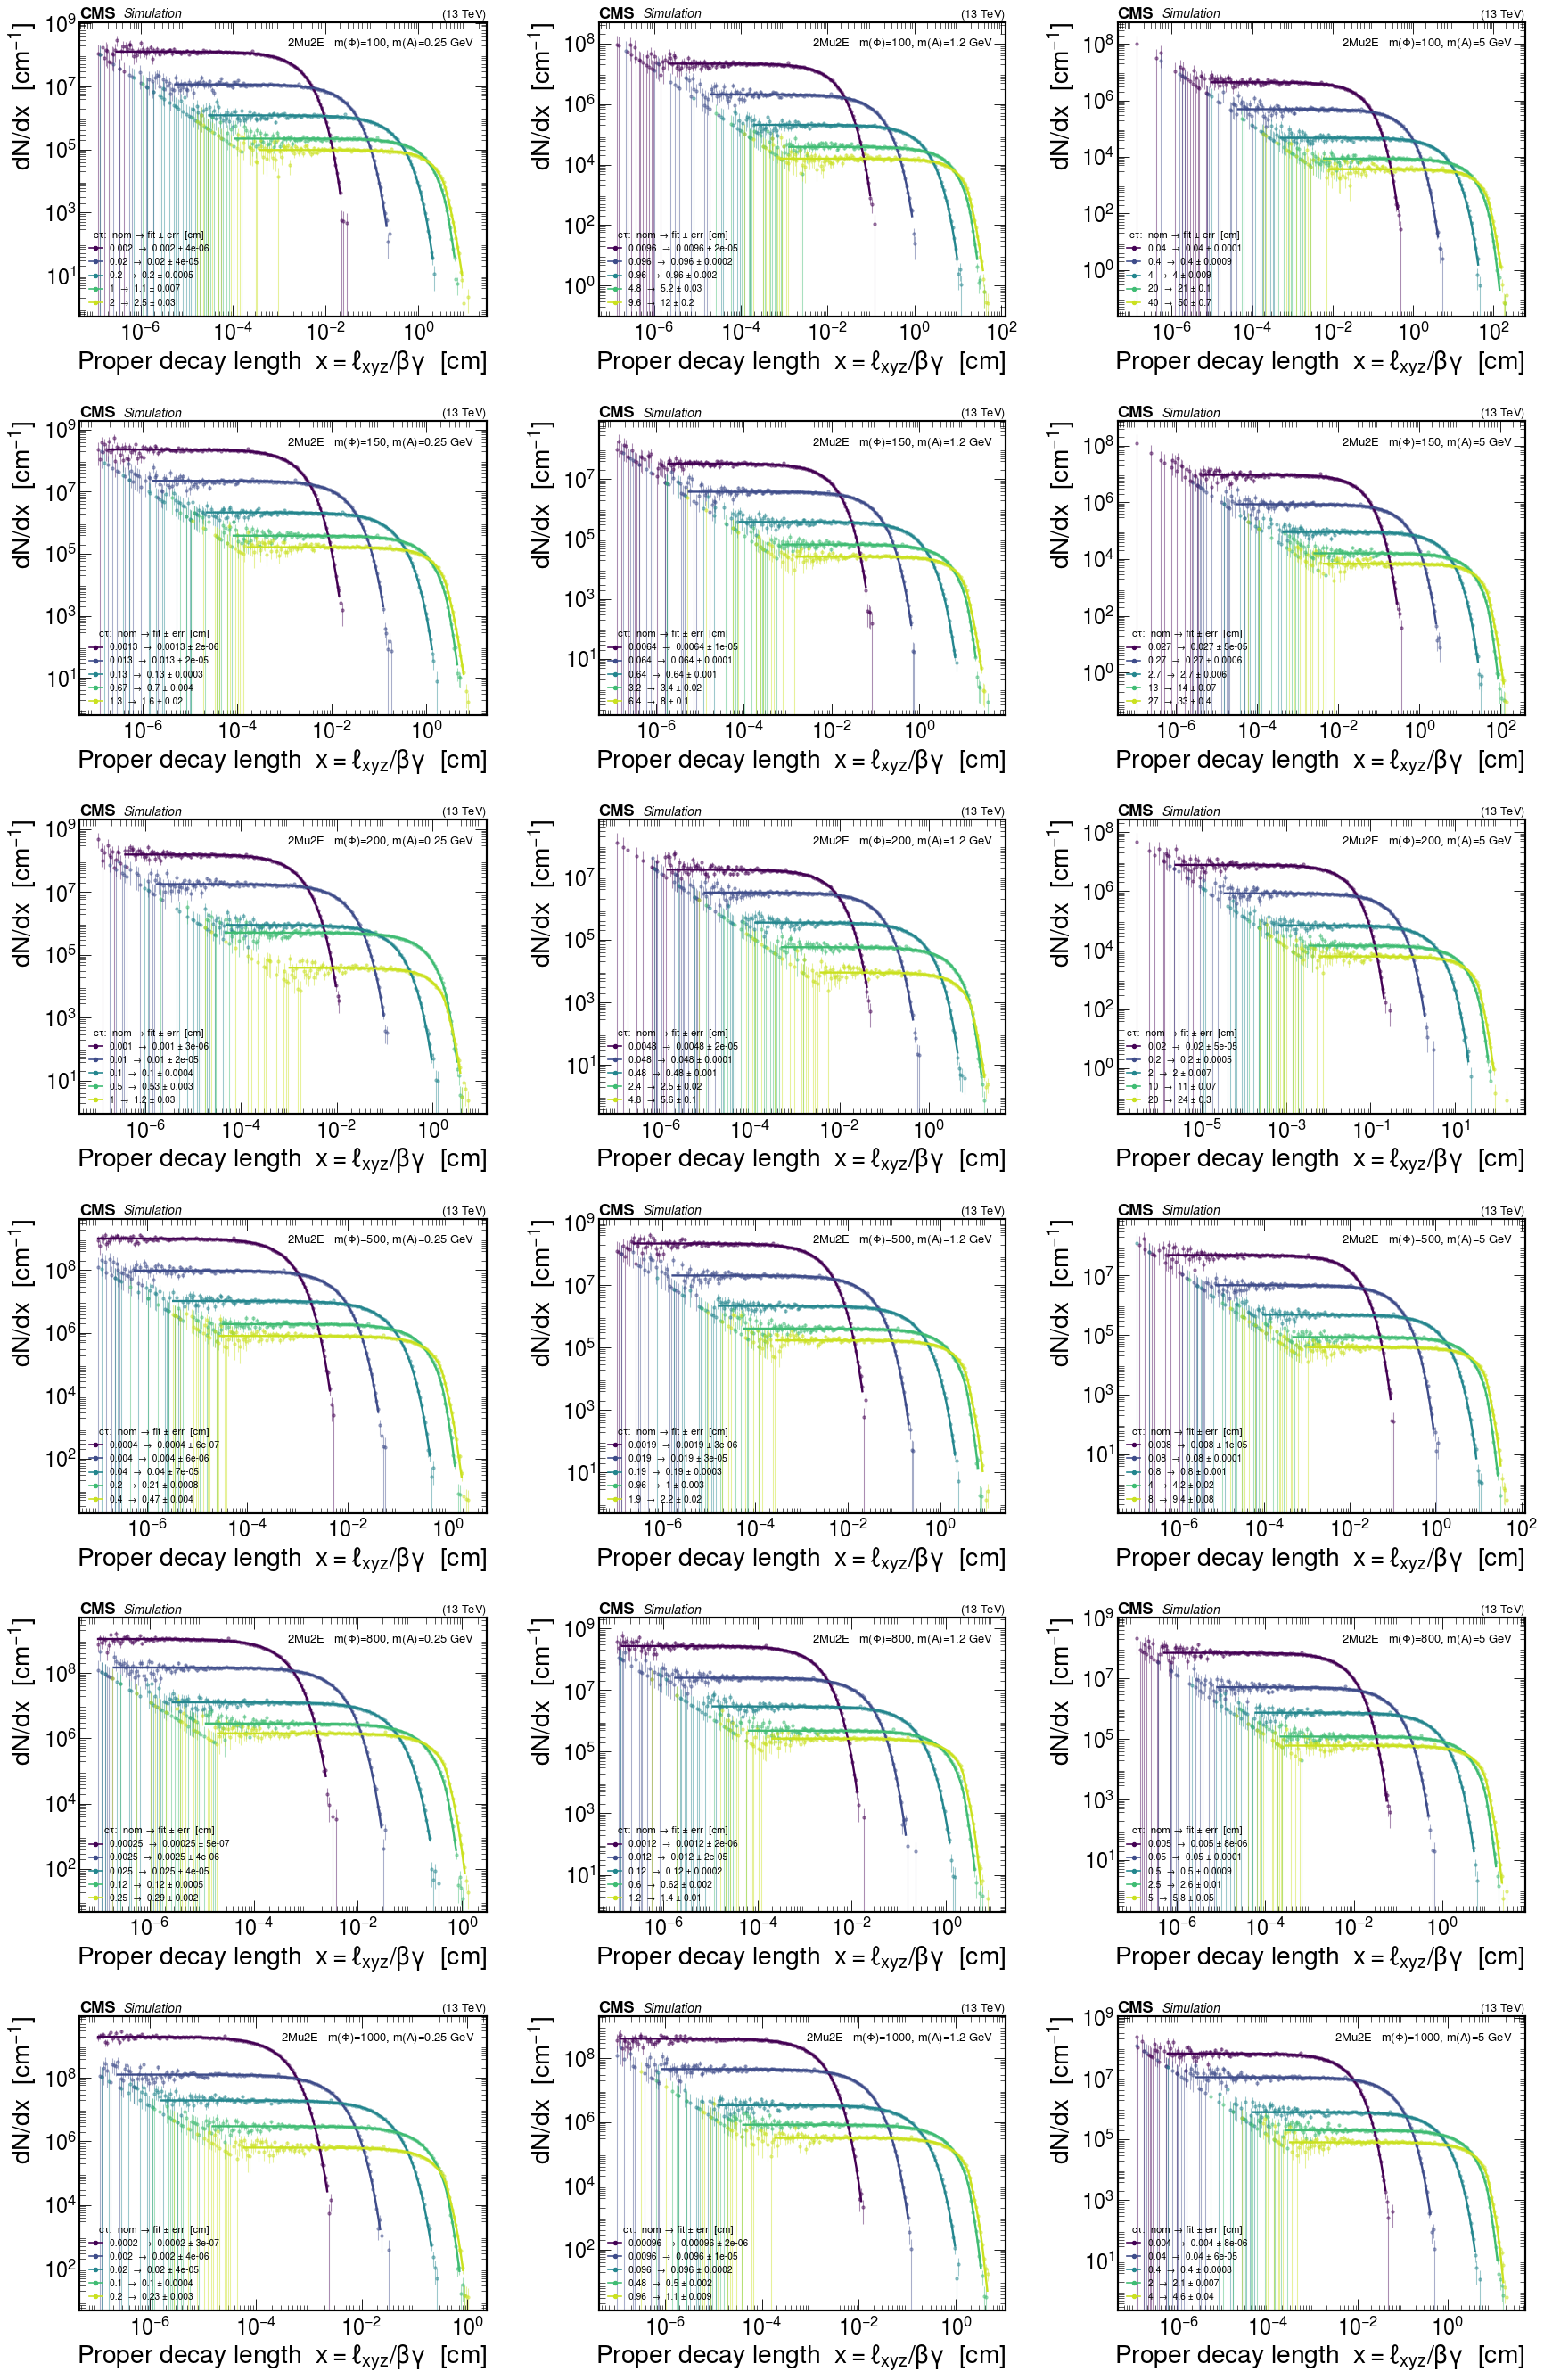

In [4]:
fig = la.plot_fit_grid(output, groups, "2Mu2E", kind="acceptance", channel=CH)


## Recovery across the full grid

The histogram mean (×) falls below 1 once the lab cap truncates the tail; the
acceptance-corrected fit (●, ±1σ) folds the cap back in. The correction recovers a
median `measured / nominal` of 1.002 over the full grid, with 119/180 samples within
±5% of nominal; in the most-truncated samples the residuals are one-sided (the fit
returns up to +10–30% above nominal), the systematic of approximating the filter's
`ρ/z` cylinder by a single radius. This is the analysis-note body figure.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/lifetime_grid_summary.pdf
acceptance-corrected, full grid: median measured/nominal = 1.002 (N=180)
faithful regime (ctau <= 1 cm): median mean/nominal = 0.9999 (N=130)


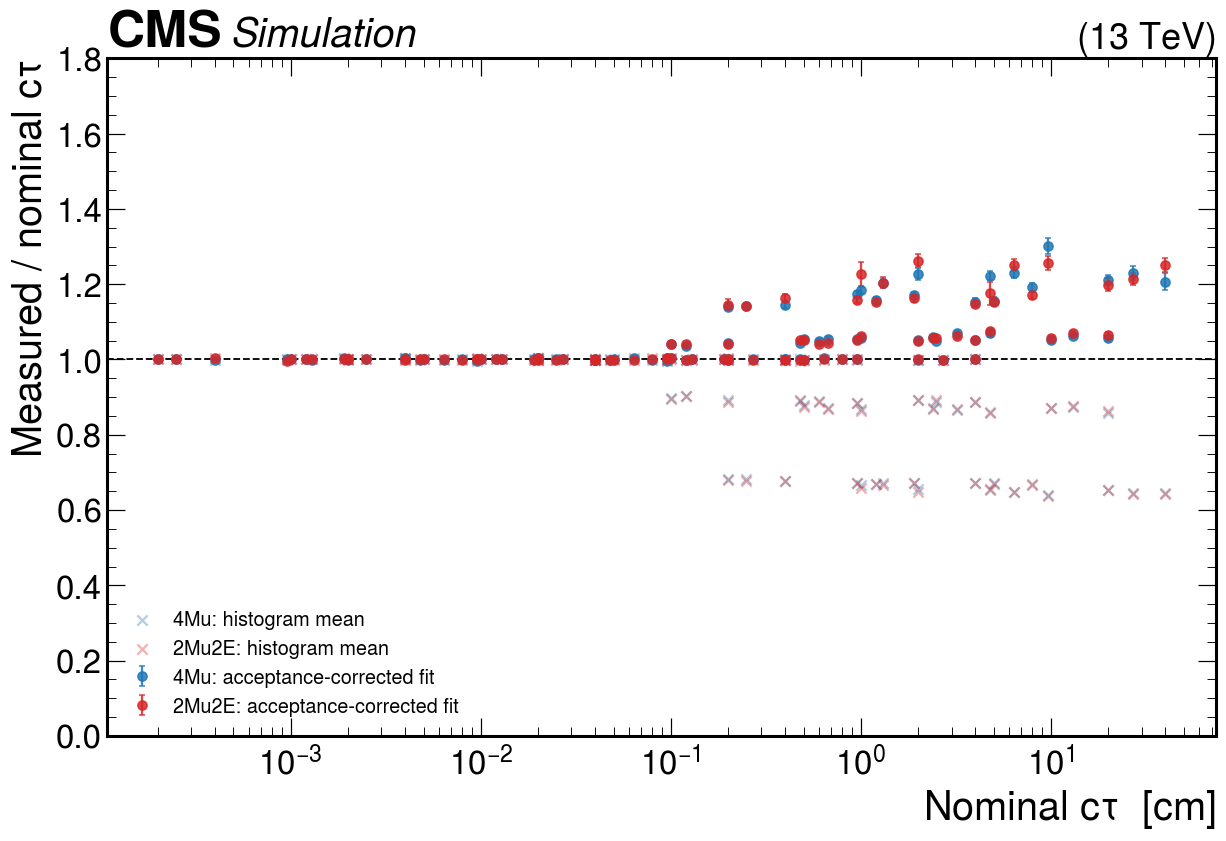

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values() if r["mass_point"][0] == ch]
    nom = np.array([r["nominal"] for r in rs])
    mean = np.array([r["mean"] for r in rs])
    acc_ = np.array([r["acceptance"] for r in rs])
    acce = np.array([r["acceptance_err"] for r in rs])
    ax.scatter(nom, mean / nom, marker="x", s=45, color=c, alpha=0.35,
               label=f"{ch}: histogram mean")
    ax.errorbar(nom, acc_ / nom, yerr=acce / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: acceptance-corrected fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.set_xscale("log")
ax.set_ylim(0, 1.8)
ax.set_xlabel(r"Nominal $c\tau$  [cm]")
ax.set_ylabel(r"Measured / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)
an_style.save(fig, "lifetime_grid_summary")

corr = [r["acceptance"] / r["nominal"] for r in rows.values()
        if np.isfinite(r["acceptance"])]
print(f"acceptance-corrected, full grid: median measured/nominal "
      f"= {np.median(corr):.3f} (N={len(corr)})")
faith = [r["mean"] / r["nominal"] for r in rows.values() if r["nominal"] <= 1.0]
print(f"faithful regime (ctau <= 1 cm): median mean/nominal = {np.median(faith):.4f} "
      f"(N={len(faith)})")


### The corrected values on their own

The acceptance-corrected `measured / nominal cτ` on a zoomed scale; the band is ±5%.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/lifetime_corrected_zoom.pdf
acceptance-corrected within +/-5% of nominal: 119/180 samples


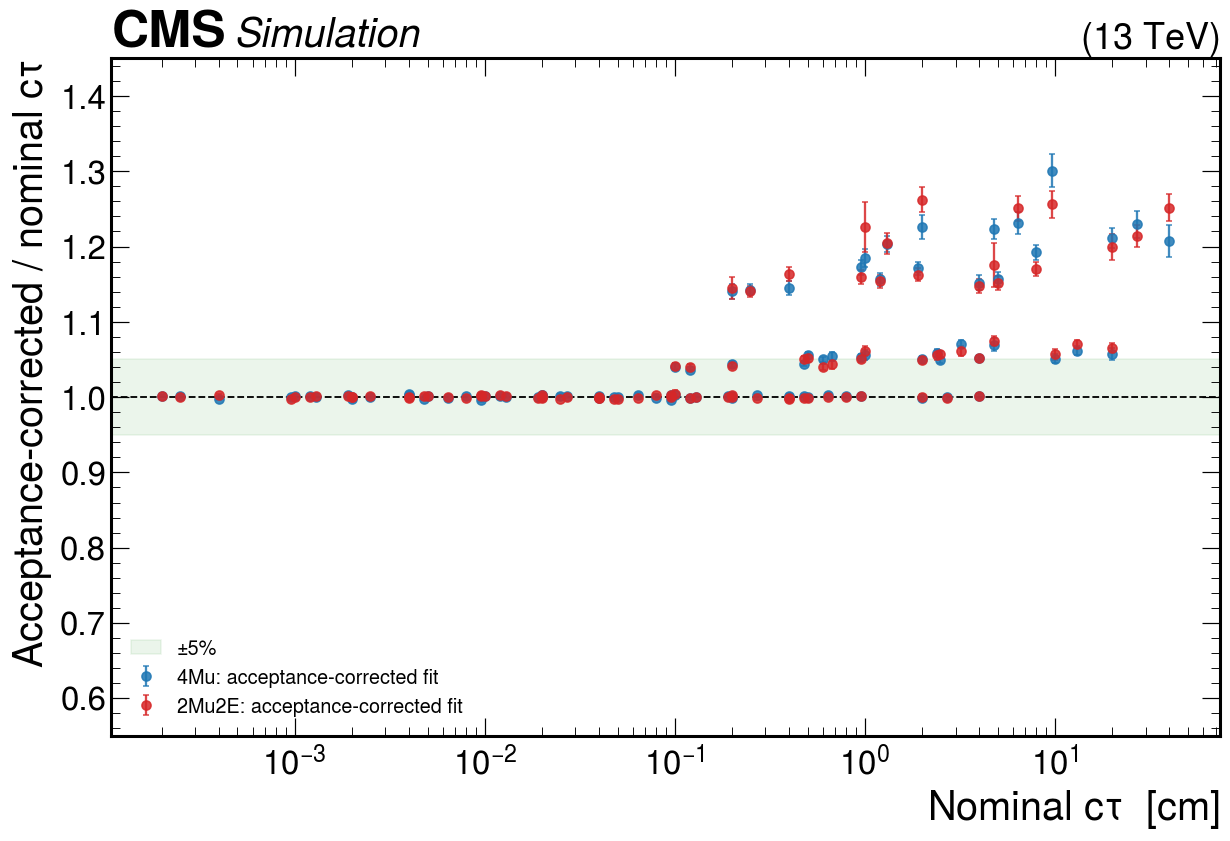

In [6]:
fig, ax = plt.subplots(figsize=(13, 8))
colors = {"4Mu": "#1f77b4", "2Mu2E": "#d62728"}
for ch, c in colors.items():
    rs = [r for r in rows.values()
          if r["mass_point"][0] == ch and np.isfinite(r["acceptance"])]
    nom = np.array([r["nominal"] for r in rs])
    acc_ = np.array([r["acceptance"] for r in rs])
    acce = np.array([r["acceptance_err"] for r in rs])
    ax.errorbar(nom, acc_ / nom, yerr=acce / nom, fmt="o", ms=6, color=c, alpha=0.85,
                capsize=2, label=f"{ch}: acceptance-corrected fit")
ax.axhline(1.0, color="k", ls="--", lw=1.2)
ax.axhspan(0.95, 1.05, color="green", alpha=0.08, label="±5%")
ax.set_xscale("log")
ax.set_ylim(0.55, 1.45)
n_out = sum(1 for r in rows.values()
            if np.isfinite(r["acceptance"])
            and not 0.55 < r["acceptance"] / r["nominal"] < 1.45)
if n_out:
    ax.text(0.02, 0.02, f"{n_out} points outside the y-window",
            transform=ax.transAxes, fontsize=11)
ax.set_xlabel(r"Nominal $c\tau$  [cm]")
ax.set_ylabel(r"Acceptance-corrected / nominal $c\tau$")
ax.legend(fontsize=13, loc="lower left", framealpha=0.9)
ax.minorticks_on()
hep.cms.label(ax=ax, data=False)
an_style.save(fig, "lifetime_corrected_zoom")

within5 = [abs(r["acceptance"] / r["nominal"] - 1) <= 0.05 for r in rows.values()
           if np.isfinite(r["acceptance"])]
print(f"acceptance-corrected within +/-5% of nominal: {sum(within5)}/{len(within5)} samples")


## Is the truncation really a single, sharp, lab-frame cap?

**Left:** fitted `R_max` for the heavily-truncated samples (mean < 0.7× nominal), where
the cap is actually constrained; the dashed line is the median. **Right:** the truncation
onset cτ per mass point versus `⟨βγ⟩`, with the one-parameter guide `C/⟨βγ⟩` (not a fit) —
constant `onset·⟨βγ⟩` demonstrates the cap lives in the lab frame; a proper-frame cut
would show no `βγ` dependence. The value `C ≈ 0.3 R_max` is expected once a lab cap is
assumed. Appendix figure for the analysis note.


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/lifetime_rmax_validation.pdf
median fitted R_max = 814 cm over 36 heavily-truncated samples
onset lab length C = onset*<bg> = 234 cm (16-84%: 215-252 cm) = 0.29 R_max, over 36 mass points (0 skipped)


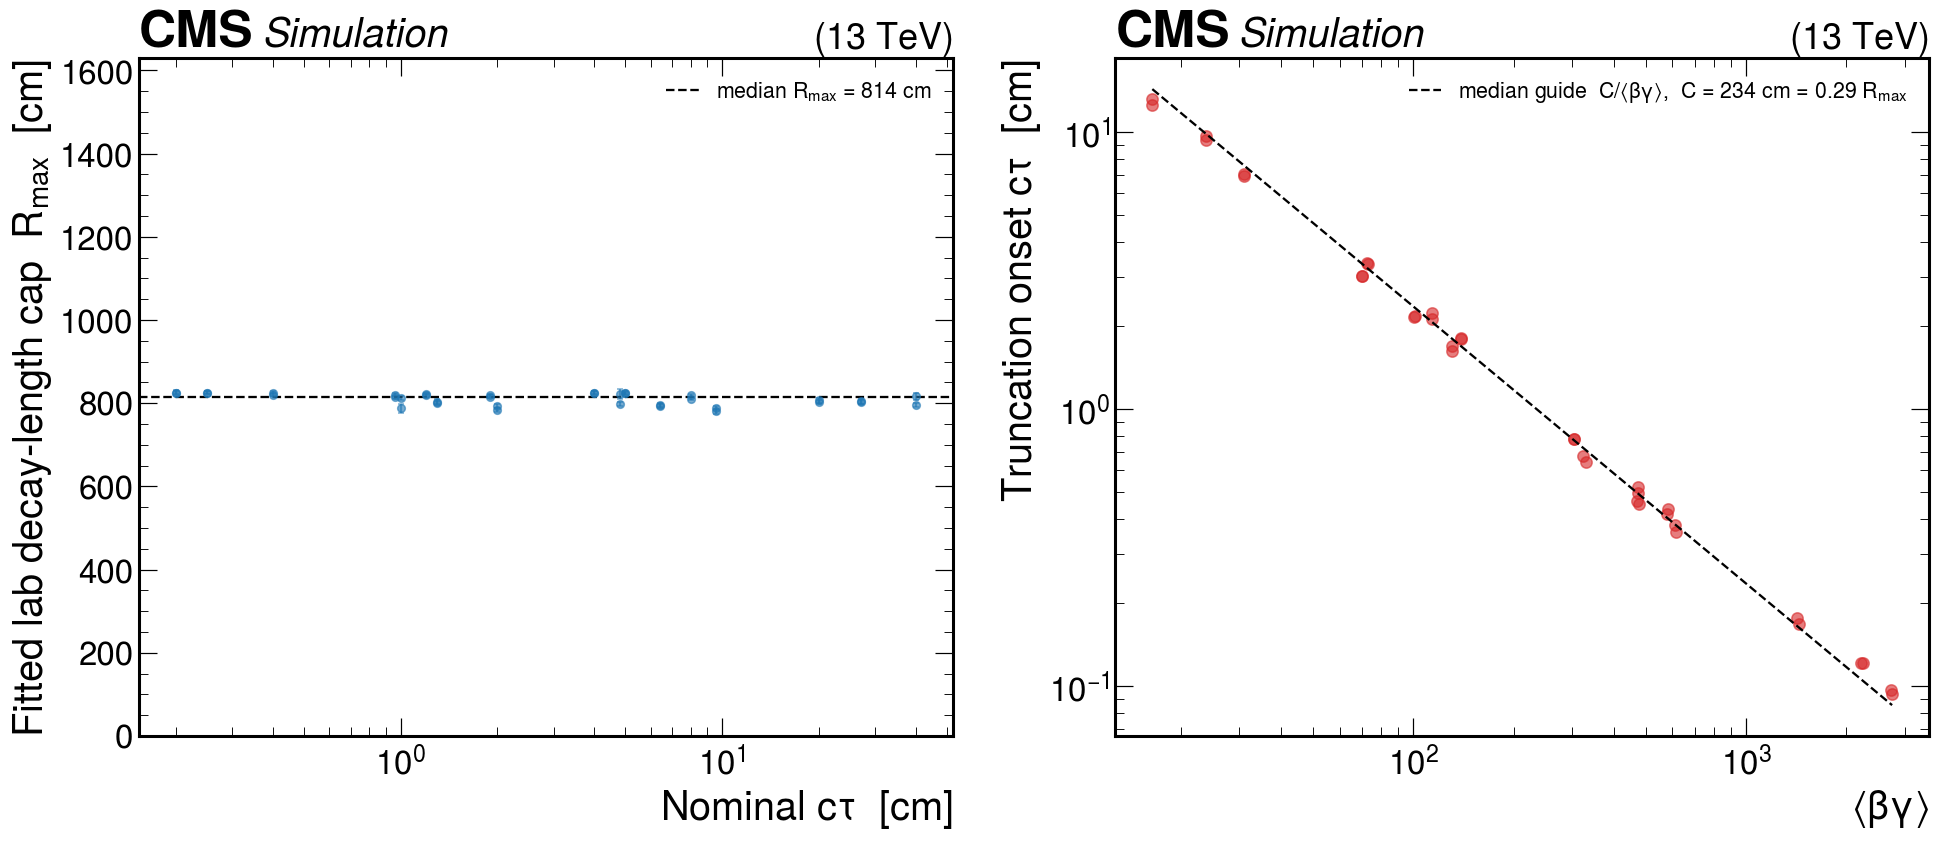

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(21, 8))

trunc = [r for r in rows.values()
         if np.isfinite(r["Rmax"]) and np.isfinite(r["Rmax_err"])
         and r["mean"] / r["nominal"] < 0.7]
nomt = np.array([r["nominal"] for r in trunc])
Rm = np.array([r["Rmax"] for r in trunc])
Rme = np.array([r["Rmax_err"] for r in trunc])
med = np.median(Rm)
axL.errorbar(nomt, Rm, yerr=Rme, fmt="o", ms=5, color="#1f77b4", alpha=0.6, capsize=2)
axL.axhline(med, color="k", ls="--", lw=1.5, label=rf"median $R_\mathrm{{max}}$ = {med:.0f} cm")
axL.set_xscale("log")
axL.set_ylim(0, 2 * med)
axL.set_xlabel(r"Nominal $c\tau$  [cm]")
axL.set_ylabel(r"Fitted lab decay-length cap  $R_\mathrm{max}$  [cm]")
axL.legend(fontsize=14)
axL.minorticks_on()
hep.cms.label(ax=axL, data=False)

onset, n_skip = [], 0
for key, samples in groups.items():
    nn = np.array([la.ctau_cm(s) for s in samples])
    rr = np.array([rows[s]["mean"] / rows[s]["nominal"] for s in samples])
    below = np.where(rr < 0.9)[0]
    if not len(below) or below[0] == 0 or rr[below[0]] == rr[below[0] - 1]:
        n_skip += 1
        continue
    i = below[0]
    x0, x1 = np.log(nn[i - 1]), np.log(nn[i])
    y0, y1 = rr[i - 1], rr[i]
    onset.append((bg_mean[key], np.exp(x0 + (0.9 - y0) * (x1 - x0) / (y1 - y0))))
onset = np.array(onset)
prod = onset[:, 0] * onset[:, 1]
C = np.median(prod)
p16, p84 = np.percentile(prod, [16, 84])
axR.scatter(onset[:, 0], onset[:, 1], s=55, color="#d62728", alpha=0.6)
bgg = np.geomspace(onset[:, 0].min(), onset[:, 0].max(), 50)
axR.plot(bgg, C / bgg, "k--", lw=1.5,
         label=rf"median guide  $C/\langle\beta\gamma\rangle$,  $C$ = {C:.0f} cm = {C/med:.2f} $R_\mathrm{{max}}$")
axR.set_xscale("log")
axR.set_yscale("log")
axR.set_xlabel(r"$\langle\beta\gamma\rangle$")
axR.set_ylabel(r"Truncation onset $c\tau$  [cm]")
axR.legend(fontsize=14)
axR.minorticks_on()
hep.cms.label(ax=axR, data=False)
an_style.save(fig, "lifetime_rmax_validation")

print(f"median fitted R_max = {med:.0f} cm over {len(trunc)} heavily-truncated samples")
print(f"onset lab length C = onset*<bg> = {C:.0f} cm (16-84%: {p16:.0f}-{p84:.0f} cm) "
      f"= {C/med:.2f} R_max, over {len(onset)} mass points ({n_skip} skipped)")


## Result

A single lab decay-length cap, consistent across all mass points and both channels,
describes the truncation well. In the faithful regime (cτ ≤ 1 cm), where no correction
is needed, the samples deliver the nominal proper lifetime at the per-mille level
(median measured/nominal = 0.9999, N = 130). Folding the cap back in as the acceptance
`ε(x) = Fβγ(R_max/x)` extends the recovery to the truncated regime with a median of
1.002 and 119/180 samples within ±5%; the residuals there are one-sided (up to +10–30%
for the most-truncated samples), reflecting the single-radius approximation to the
filter's `ρ < 740 cm` / `|z| < 960 cm` cylinder. Statistics are ~50× the original
`max_files=1` pass (0.994 faithful median, 120/178 within ±5%, R_max ≈ 825 cm from 36
samples); the coverage metric is comparable, the faithful-regime closure is much
sharper, and the lab-frame-scaling test now includes every mass point.

The same cap independently explains why the central production's gen-filter vertex cut
cannot be emulated on these samples: decays beyond `R_max` are absent by construction,
so the filter-emulation channel (`genFilterEmulation`) measures a lifetime-flat lepton
acceptance rather than the central production's lifetime-dependent filter efficiency.
